### What are the key factors that predict fraudulent customer?

Your model has identified these as key predictors: amount, oldbalanceDest, newbalanceOrig, type (e.g., CASH_OUT, TRANSFER), isFraud

#### Do these factors make sense? If yes, how?

Yes — each factor logically contributes to predicting fraud, including type:

Feature	   ---     Why It Makes Sense

amount	---        Large, sudden transfers are a common fraud tactic.

oldbalanceDest	---Zero balance before receiving money could indicate a newly opened or mule account.

newbalanceOrig	---Sudden drops to zero can be a red flag, especially after high-value transfers.

type        	---Certain types like TRANSFER and CASH_OUT are high-risk compared to PAYMENT.

### What kind of prevention should be adopted while the company updates its infrastructure?

Here's a targeted prevention strategy based on these features:

Factor	---Prevention Tactic

amount	---Set adaptive thresholds for transaction value, and flag high-volume accounts.

type	---Apply stricter rules on TRANSFER and CASH_OUT transactions.

oldbalanceDest = 0	---Flag destinations that receive large sums but had zero balance.

newbalanceOrig = 0---	Alert when origin accounts are drained completely after transaction.

Combined check	----Block or verify when TRANSFER/CASH_OUT + large amount + destination=0.

### Assuming these actions have been implemented, how would you determine if they work?

Track these effectiveness indicators:

Metric	---What It Tells You
🔍 Precision & Recall	---Are you catching more frauds without many false alarms?

📉 Drop in fraud losses---	Compare monetary fraud loss before and after implementation.

🔄 False Positive Rate---	Are you wrongly flagging real users?

✅ AUC-ROC Score---	Overall model discriminative ability.

🧪 A/B Testing---	Test infrastructure with vs. without rules on type + amount, etc.

👥 User Trust Feedback	---Survey or support ticket trends can reveal user satisfaction.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Loading Dataset:
df = pd.read_csv("Fraud.csv")
# Reading top 4 records
df.head(4)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0


In [ ]:
# shape of dataset
df.shape

(6362620, 11)

In [ ]:
# names of columns
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
#get information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
# find out the number of null values in each columns
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

### In this Dataset ,  there are no missing value  . So we dont need to handle missing value  

In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [ ]:
# Exploring transaction type
print(df.type.value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [ ]:
import plotly.express as px
# Get value counts
type_counts = df["type"].value_counts().reset_index()
type_counts.columns = ['Transaction Type', 'Count']

# Plot
figure = px.pie(type_counts,
                names='Transaction Type',
                values='Count',
                hole=0.5,
                title="Distribution of Transaction Type")
figure.show()

### Treat Multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

def calculate_vif(df):
    vif = pd.DataFrame()
    vif["variables"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif

# Drop non-numeric columns and handle NaNs
df_numeric = df.select_dtypes(include=[np.number]).dropna()

# Scale features to improve stability
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

# Calculate VIF
vif_df = calculate_vif(df_scaled)
print(vif_df)

        variables         VIF
0            step    1.003137
1          amount    3.771634
2   oldbalanceOrg  502.913267
3  newbalanceOrig  504.282321
4  oldbalanceDest   66.101079
5  newbalanceDest   76.200749
6         isFraud    1.186855
7  isFlaggedFraud    1.002562


In [ ]:
# The below two columns are highly multicollinearity . so , we drop them.
df = df.drop(columns=['oldbalanceOrg'])
df = df.drop(columns=['newbalanceDest'])


In [ ]:
# Multicollinearity after droping the highly related column

# Drop non-numeric columns and handle NaNs
df_numeric = df.select_dtypes(include=[np.number]).dropna()

# Scale features to improve stability
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

# Calculate VIF
vif_df = calculate_vif(df_scaled)
print(vif_df)

        variables       VIF
0            step  1.002067
1          amount  1.103294
2  newbalanceOrig  1.005660
3  oldbalanceDest  1.102222
4         isFraud  1.009663
5  isFlaggedFraud  1.002062


### Treat outlier

In [ ]:
# convert categorical data into numeric
df["type"] = df["type"].map({"CASH_OUT": 1, "PAYMENT": 2,
                                 "CASH_IN": 3, "TRANSFER": 4,
                                 "DEBIT": 5})


print(df.head())

   step  type    amount     nameOrig  newbalanceOrig     nameDest  \
0     1     2   9839.64  C1231006815       160296.36  M1979787155   
1     1     2   1864.28  C1666544295        19384.72  M2044282225   
2     1     4    181.00  C1305486145            0.00   C553264065   
3     1     1    181.00   C840083671            0.00    C38997010   
4     1     2  11668.14  C2048537720        29885.86  M1230701703   

   oldbalanceDest  isFraud  isFlaggedFraud  
0             0.0        0               0  
1             0.0        0               0  
2             0.0        1               0  
3         21182.0        1               0  
4             0.0        0               0  


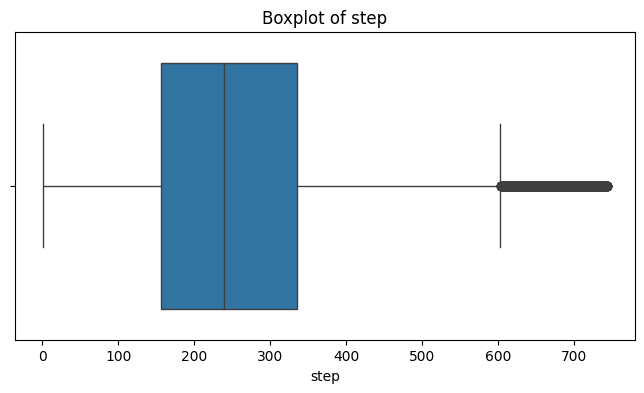

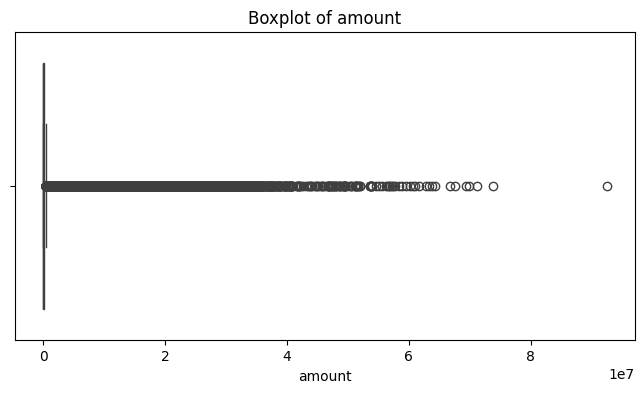

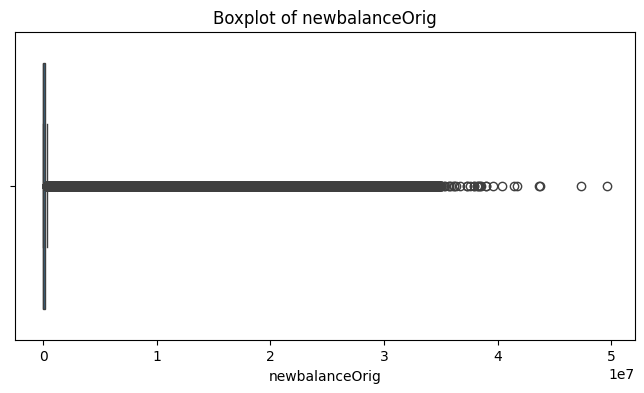

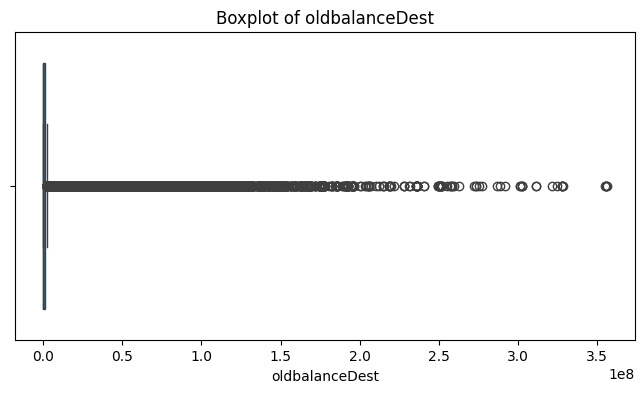

In [ ]:
# Visualize outliers for each numeric column
numeric_cols = ['step','amount',  'newbalanceOrig', 'oldbalanceDest']
#df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


In [ ]:
# appling caping
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower_bound, lower_bound,
                          np.where(df[column] > upper_bound, upper_bound, df[column]))
    return df

# Apply to all numeric columns
df_capped = df.copy()
for col in numeric_cols:
    df_capped = cap_outliers_iqr(df_capped, col)

print("Shape after outlier capping:", df_capped.shape)


Shape after outlier capping: (6362620, 9)


In [ ]:
# Treat outliers using the IQR method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply to all numeric columns
df_cleaned = df.copy()
for col in numeric_cols:
    df_cleaned = remove_outliers_iqr(df_cleaned, col)

print("Shape after outlier removal:", df_cleaned.shape)


Shape after outlier removal: (4286770, 9)


Why Capping is Better Here:

Keeps all rows in the dataset.

Reduces the influence of extreme outlier values.

Retains statistical power, which is useful for rare-event modeling like fraud detection.


In [ ]:
# Appling capping to the dataset
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping using np.where
    df[column] = np.where(df[column] < lower_bound, lower_bound,
                          np.where(df[column] > upper_bound, upper_bound, df[column]))
    return df

In [ ]:
df_capped = df.copy()  # Preserve the original data

for col in numeric_cols:
    df_capped = cap_outliers_iqr(df_capped, col)


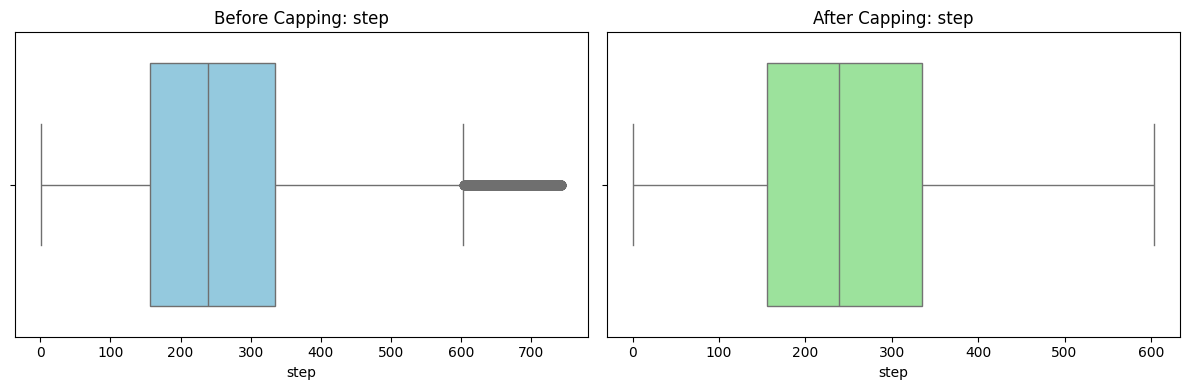

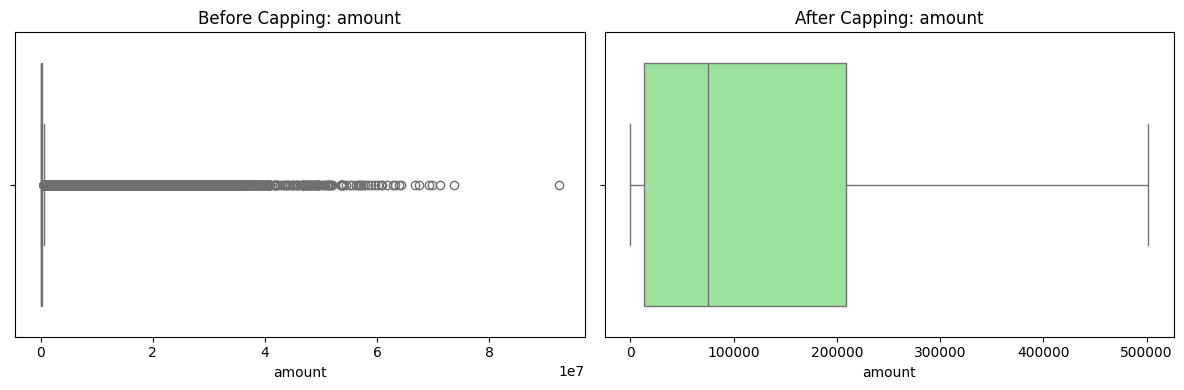

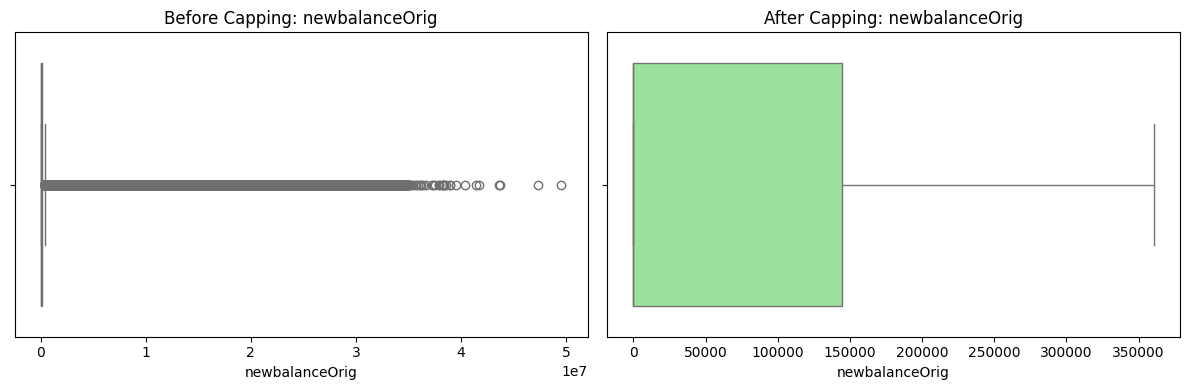

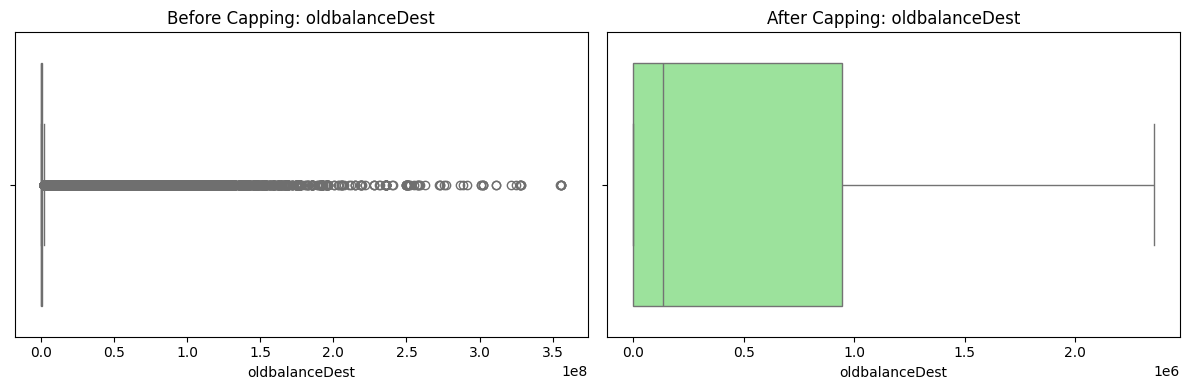

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Before Capping: {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_capped[col], color='lightgreen')
    plt.title(f'After Capping: {col}')

    plt.tight_layout()
    plt.show()


### spiltting the dataset

In [ ]:
# Spiltting the dataset
from sklearn.model_selection import train_test_split

# Drop multiple columns correctly by passing a list
X = df_capped.drop(["isFraud", "nameDest", "step", "nameOrig", "isFlaggedFraud"], axis=1).values

# Target variable
y = df_capped["isFraud"].values


In [ ]:
# training a machine learning model
from sklearn.tree import DecisionTreeClassifier
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.10, random_state=42)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_classification_model(model, X_train, X_test, y_train, y_test, plot=True):
    # Fit the model
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Evaluate accuracy and confusion matrix
    test_acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)


    # Print results
    print(f"\n📌 Model: {model.__class__.__name__}")
    print("Confusion Matrix:\n", cm)
    print(f"Test Accuracy     : {test_acc:.4f}")

    if plot:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"Confusion Matrix: {model.__class__.__name__}")
        plt.show()

    return {
        "model": model.__class__.__name__,
        "test_accuracy": test_acc,
        "confusion_matrix": cm,

    }


In [ ]:
from sklearn.tree import DecisionTreeClassifier


📌 Model: DecisionTreeClassifier
Confusion Matrix:
 [[634931    514]
 [   772     45]]
Test Accuracy     : 0.9980


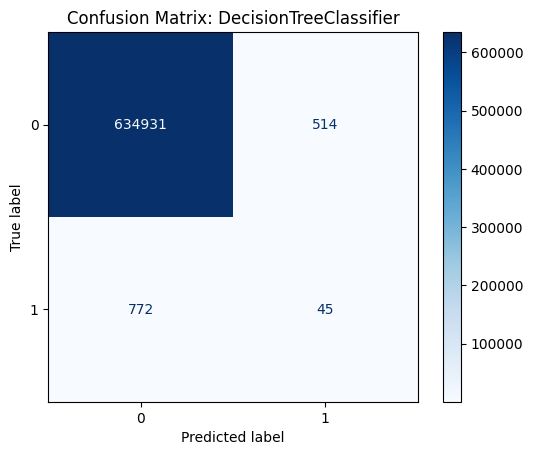

{'model': 'DecisionTreeClassifier',
 'test_accuracy': 0.9979788200458302,
 'confusion_matrix': array([[634931,    514],
        [   772,     45]])}

In [ ]:
evaluate_classification_model(DecisionTreeClassifier(),xtrain, xtest, ytrain, ytest)